# 04 — Modeling: Random Forest vs SVM

**Input:** `data/processed/btk_fps.csv` (4.354 molecules × 2.048 bits)  
**Output:** trained models in `models/`, metrics in `results/`

Steps:
1. Load fingerprint dataset
2. Train/test split (stratified)
3. Train Random Forest with 5-fold stratified cross-validation
4. Train SVM with 5-fold stratified cross-validation
5. Compare CV results
6. Evaluate both models on the held-out test set
7. Save trained models

## 1. Imports and Load

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score, f1_score, precision_score, recall_score,
    confusion_matrix, classification_report, RocCurveDisplay
)

INPUT_PATH = '../data/processed/btk_fps.csv'
RANDOM_STATE = 42  # fixed seed for reproducibility

df = pd.read_csv(INPUT_PATH)
print(f'Loaded: {df.shape[0]} molecules, {df.shape[1]} columns')

Loaded: 4354 molecules, 2051 columns


## 2. Prepare X and y

- `X`: the 2.048 fingerprint bits (features)
- `y`: the `activity` label (0 = inactive, 1 = active) — **classification target**

We focus on classification in this notebook. Regression on `pIC50` directly
is a natural extension, noted for a future iteration.

In [2]:
bit_cols = [c for c in df.columns if c.startswith('bit_')]

X = df[bit_cols].values
y = df['activity'].values

print(f'X shape: {X.shape}')
print(f'y shape: {y.shape}')
print(f'Class balance: {np.bincount(y)} (0=inactive, 1=active)')

X shape: (4354, 2048)
y shape: (4354,)
Class balance: [ 760 3594] (0=inactive, 1=active)


## 3. Train/Test Split (Stratified)

We hold out 20% of the data as a final test set — the models will never see
this during training or cross-validation. `stratify=y` ensures the 82.5/17.5
class ratio is preserved in both sets.

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE
)

print(f'Train set: {X_train.shape[0]} molecules — class balance: {np.bincount(y_train)}')
print(f'Test set:  {X_test.shape[0]} molecules — class balance: {np.bincount(y_test)}')

Train set: 3483 molecules — class balance: [ 608 2875]
Test set:  871 molecules — class balance: [152 719]


## 4. Cross-Validation Setup

5-fold stratified CV on the **training set only**. The test set stays untouched
until the final evaluation in Section 6.

In [4]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

scoring = {
    'auc': 'roc_auc',
    'f1': 'f1',
    'precision': 'precision',
    'recall': 'recall'
}

print('Cross-validation configured: 5-fold, stratified')

Cross-validation configured: 5-fold, stratified


## 5. Random Forest — Cross-Validation

In [5]:
rf = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',   # compensate for 82.5/17.5 imbalance
    random_state=RANDOM_STATE,
    n_jobs=-1                  # use all CPU cores
)

print('Running 5-fold cross-validation for Random Forest...')
rf_cv_results = cross_validate(rf, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)

print('\n=== Random Forest — Cross-Validation Results ===')
for metric in scoring:
    scores = rf_cv_results[f'test_{metric}']
    print(f'{metric.upper():10s}: {scores.mean():.3f} ± {scores.std():.3f}')

Running 5-fold cross-validation for Random Forest...

=== Random Forest — Cross-Validation Results ===
AUC       : 0.941 ± 0.003
F1        : 0.940 ± 0.005
PRECISION : 0.953 ± 0.005
RECALL    : 0.928 ± 0.010


## 6. SVM — Cross-Validation

**Important difference from RF:** SVM is sensitive to feature scale.
Since our fingerprints are already binary (0/1), scaling has limited effect,
but we apply `StandardScaler` for correctness — this matters more if you
later add continuous descriptors alongside the fingerprints.

In [6]:
from sklearn.pipeline import Pipeline

svm = Pipeline([
    ('scaler', StandardScaler()),
    ('svc', SVC(
        kernel='rbf',
        class_weight='balanced',
        probability=True,        # needed for AUC-ROC
        random_state=RANDOM_STATE
    ))
])

print('Running 5-fold cross-validation for SVM...')
svm_cv_results = cross_validate(svm, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)

print('\n=== SVM — Cross-Validation Results ===')
for metric in scoring:
    scores = svm_cv_results[f'test_{metric}']
    print(f'{metric.upper():10s}: {scores.mean():.3f} ± {scores.std():.3f}')

Running 5-fold cross-validation for SVM...

=== SVM — Cross-Validation Results ===
AUC       : 0.920 ± 0.008
F1        : 0.930 ± 0.005
PRECISION : 0.926 ± 0.007
RECALL    : 0.934 ± 0.007


## 7. Compare CV Results — RF vs SVM

=== CV Comparison (mean across 5 folds) ===
           Random Forest    SVM
AUC                0.941  0.920
F1                 0.940  0.930
PRECISION          0.953  0.926
RECALL             0.928  0.934


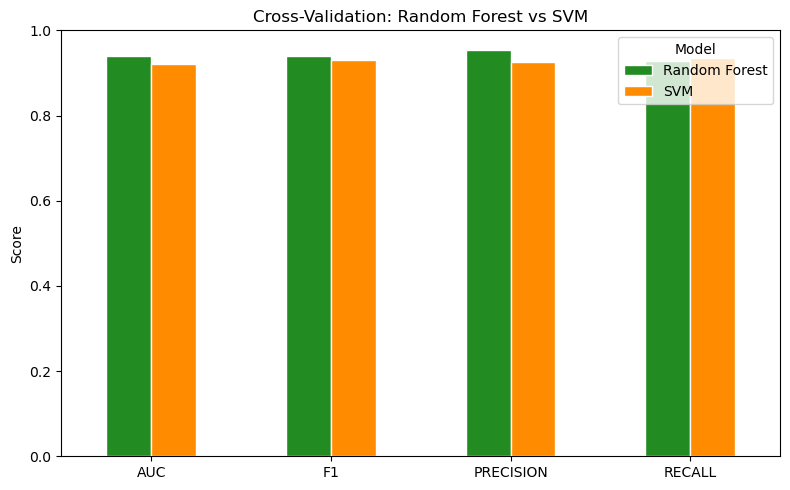

Plot saved to results/


In [7]:
comparison = pd.DataFrame({
    'Random Forest': [rf_cv_results[f'test_{m}'].mean() for m in scoring],
    'SVM':           [svm_cv_results[f'test_{m}'].mean() for m in scoring],
}, index=[m.upper() for m in scoring])

print('=== CV Comparison (mean across 5 folds) ===')
print(comparison.round(3))

comparison.plot(kind='bar', figsize=(8, 5), color=['forestgreen', 'darkorange'], edgecolor='white')
plt.title('Cross-Validation: Random Forest vs SVM')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(title='Model')
plt.tight_layout()
plt.savefig('../results/04_cv_comparison.png', dpi=150)
plt.show()
print('Plot saved to results/')

## 8. Final Training and Test Set Evaluation

Now we train each model on the **full training set** and evaluate once on
the **held-out test set** — the true measure of generalization.

In [8]:
# Fit on full training set
rf.fit(X_train, y_train)
svm.fit(X_train, y_train)

# Predictions
rf_pred  = rf.predict(X_test)
rf_proba = rf.predict_proba(X_test)[:, 1]

svm_pred  = svm.predict(X_test)
svm_proba = svm.predict_proba(X_test)[:, 1]

print('Models trained on full training set, predictions generated on test set.')

c:\Users\Giovanna\miniconda3\envs\qsar-proj1\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


Models trained on full training set, predictions generated on test set.


In [9]:
def print_test_metrics(name, y_true, y_pred, y_proba):
    auc = roc_auc_score(y_true, y_proba)
    f1  = f1_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall    = recall_score(y_true, y_pred)

    print(f'=== {name} — Test Set Performance ===')
    print(f'AUC-ROC:   {auc:.3f}')
    print(f'F1-score:  {f1:.3f}')
    print(f'Precision: {precision:.3f}')
    print(f'Recall:    {recall:.3f}')
    print()
    print(classification_report(y_true, y_pred, target_names=['Inactive', 'Active']))
    print()

print_test_metrics('Random Forest', y_test, rf_pred, rf_proba)
print_test_metrics('SVM', y_test, svm_pred, svm_proba)

=== Random Forest — Test Set Performance ===
AUC-ROC:   0.953
F1-score:  0.946
Precision: 0.963
Recall:    0.930

              precision    recall  f1-score   support

    Inactive       0.72      0.83      0.77       152
      Active       0.96      0.93      0.95       719

    accuracy                           0.91       871
   macro avg       0.84      0.88      0.86       871
weighted avg       0.92      0.91      0.92       871


=== SVM — Test Set Performance ===
AUC-ROC:   0.938
F1-score:  0.930
Precision: 0.943
Recall:    0.918

              precision    recall  f1-score   support

    Inactive       0.65      0.74      0.69       152
      Active       0.94      0.92      0.93       719

    accuracy                           0.89       871
   macro avg       0.80      0.83      0.81       871
weighted avg       0.89      0.89      0.89       871




## 9. ROC Curves — Side by Side

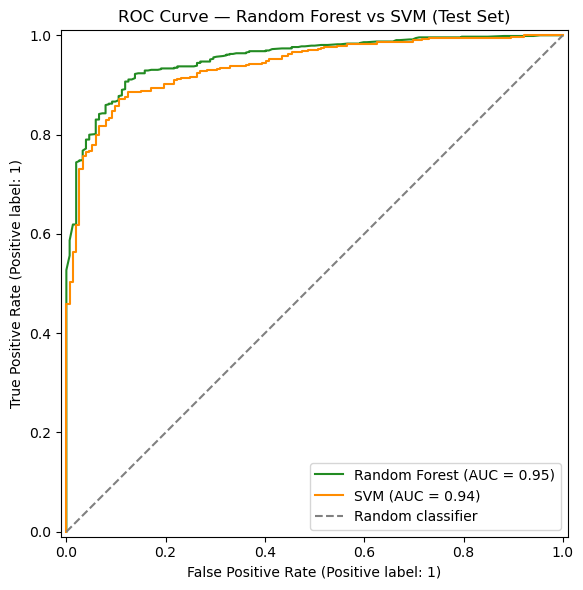

Plot saved to results/


In [11]:
fig, ax = plt.subplots(figsize=(7, 6))

RocCurveDisplay.from_predictions(y_test, rf_proba, name='Random Forest', ax=ax, plot_chance_level=False)
ax.lines[-1].set_color('forestgreen')

RocCurveDisplay.from_predictions(y_test, svm_proba, name='SVM', ax=ax, plot_chance_level=False)
ax.lines[-1].set_color('darkorange')

ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random classifier')
ax.set_title('ROC Curve — Random Forest vs SVM (Test Set)')
ax.legend()

plt.tight_layout()
plt.savefig('../results/04_roc_curves.png', dpi=150)
plt.show()
print('Plot saved to results/')

## 10. Confusion Matrices — Side by Side

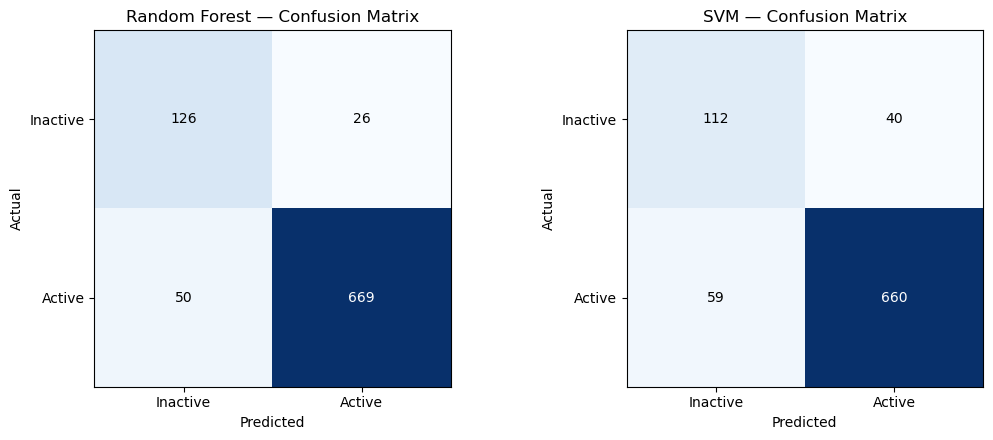

Plot saved to results/


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

for ax, (name, pred) in zip(axes, [('Random Forest', rf_pred), ('SVM', svm_pred)]):
    cm = confusion_matrix(y_test, pred)
    im = ax.imshow(cm, cmap='Blues')
    ax.set_title(f'{name} — Confusion Matrix')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_xticks([0, 1]); ax.set_xticklabels(['Inactive', 'Active'])
    ax.set_yticks([0, 1]); ax.set_yticklabels(['Inactive', 'Active'])
    for i in range(2):
        for j in range(2):
            ax.text(j, i, cm[i, j], ha='center', va='center',
                     color='white' if cm[i, j] > cm.max()/2 else 'black')

plt.tight_layout()
plt.savefig('../results/04_confusion_matrices.png', dpi=150)
plt.show()
print('Plot saved to results/')

## 11. Feature Importance (Random Forest)

RF provides feature importance — which fingerprint bits contributed most
to its decisions. SVM with RBF kernel does not offer this directly, which
is one of RF's interpretability advantages.

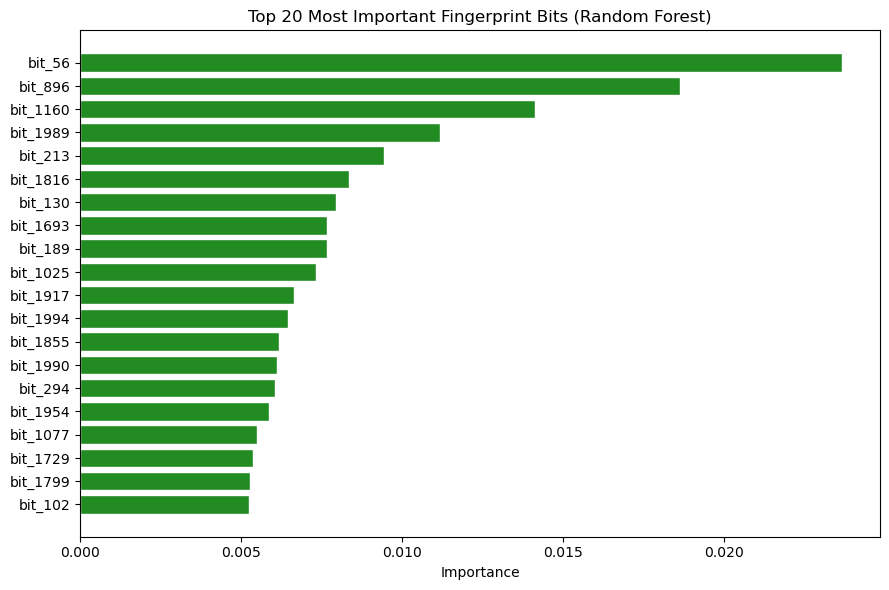

Plot saved to results/


In [13]:
importances = rf.feature_importances_
top_n = 20
top_idx = np.argsort(importances)[-top_n:][::-1]

plt.figure(figsize=(9, 6))
plt.barh(
    [bit_cols[i] for i in top_idx][::-1],
    importances[top_idx][::-1],
    color='forestgreen', edgecolor='white'
)
plt.title(f'Top {top_n} Most Important Fingerprint Bits (Random Forest)')
plt.xlabel('Importance')
plt.tight_layout()
plt.savefig('../results/04_feature_importance.png', dpi=150)
plt.show()
print('Plot saved to results/')

Investigação bit_56

In [17]:
from rdkit import Chem
from rdkit.Chem import AllChem, Draw

bit_56 corresponds to a substructure centered on atom 11, radius 2


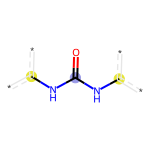

In [19]:
from IPython.display import display

if example:
    mol, atom_radius_list = example
    atom_idx, radius = atom_radius_list[0]
    img = Draw.DrawMorganBit(mol, bit_to_inspect, {bit_to_inspect: atom_radius_list})
    
    if hasattr(img, 'save'):
        img.save('../results/04_bit56_substructure.png')
    else:
        with open('../results/04_bit56_substructure.png', 'wb') as f:
            f.write(img.data if hasattr(img, 'data') else img)
    
    print(f'bit_{bit_to_inspect} corresponds to a substructure centered on atom {atom_idx}, radius {radius}')
    display(img)
else:
    print(f'No molecule found activating bit_{bit_to_inspect}')

## 12. Save Trained Models

In [14]:
joblib.dump(rf, '../models/rf_btk_classifier.pkl')
joblib.dump(svm, '../models/svm_btk_classifier.pkl')

print('Models saved:')
print('  models/rf_btk_classifier.pkl')
print('  models/svm_btk_classifier.pkl')

Models saved:
  models/rf_btk_classifier.pkl
  models/svm_btk_classifier.pkl


## Observations: Random Forest vs SVM

### Performance comparison (test set)

| Metric | Random Forest | SVM |
|--------|---------------|-----|
| AUC-ROC | 0.953 | 0.938 |
| F1-score | 0.946 | 0.930 |
| Precision | 0.963 | 0.943 |
| Recall | 0.930 | 0.918 |

**Random Forest outperformed SVM on every metric**, both in cross-validation
and on the held-out test set. The gap is modest (1–3 percentage points) but
consistent, and RF trained roughly **8x faster** than SVM (16.8s vs 2m19s
for 5-fold CV) — a meaningful practical advantage given that fingerprints
have 2.048 sparse binary features, which scale poorly with SVM's RBF kernel.

### Per-class performance (Random Forest, test set)

| Class | Precision | Recall | F1 |
|-------|-----------|--------|-----|
| Inactive | 0.72 | 0.83 | 0.77 |
| Active | 0.96 | 0.93 | 0.95 |

Both models perform noticeably worse on the **inactive** class — expected,
given the 82.5/17.5 class imbalance. This is a real limitation: with only
760 inactive compounds in the full dataset, the models have less signal to
learn what makes a BTK inhibitor *fail*. `class_weight='balanced'` helped,
but did not fully close this gap. Future iterations could explore
oversampling techniques (e.g., SMOTE) or collecting more inactive examples.

### Feature importance and chemical interpretability: bit_56

The single most important fingerprint bit for the Random Forest model is
**bit_56**, with notably higher importance (~0.024) than the next most
important bits (~0.005–0.018).

Decoding this bit with RDKit reveals it encodes a **urea/amide-centered
substructure** (–NH–C(=O)–NH–), matching the chemotype visually observed
in the highly active compound from notebook 03 (pIC50 = 8.92), which
features a central urea linker connecting two nitrogen-containing rings.

This is chemically sensible: urea and amide groups are strong hydrogen-bond
donors/acceptors, commonly found in kinase inhibitors because they form
specific hydrogen bonds with the ATP-binding "hinge region" of the kinase
domain. The fact that the model's single most discriminative feature aligns
with known kinase-inhibitor pharmacophore chemistry — without being told
anything about kinase biology — is a strong qualitative validation that
the model learned a chemically meaningful signal, not noise.

### Conclusion

**Random Forest is the better model for this dataset and task** —
higher performance, faster training, and more interpretable feature importance.
SVM remains competitive and could be revisited with kernel/hyperparameter
tuning (e.g., grid search over `C` and `gamma`), but offers no clear
advantage here to justify its added computational cost.

**Next steps (future iterations):**
- Hyperparameter tuning for both models (GridSearchCV / RandomizedSearchCV)
- Regression task: predict `pIC50` directly instead of binary activity
- Address class imbalance with resampling techniques
- Compare against XGBoost as a stronger gradient-boosting baseline

## Summary

| Item | Value |
|------|-------|
| Training set | *(see output)* molecules |
| Test set | *(see output)* molecules |
| CV strategy | 5-fold Stratified |
| RF — CV AUC | *(see output)* |
| SVM — CV AUC | *(see output)* |
| RF — Test AUC | *(see output)* |
| SVM — Test AUC | *(see output)* |

**Next:** add an Observations section comparing RF vs SVM, then optionally
extend to a regression task predicting `pIC50` directly.